<a href="https://colab.research.google.com/github/YannisBtw/ITMO_Python-2.0/blob/main/lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №6: Очистка и трансформация данных. pandas

**ФИО**: Ян Ломаченко Станиславович

**ИСУ**: 505115

**Группа**: P3120

Ссылка на **[Google Colab](https://colab.research.google.com/drive/1ozo--qB4bAbOz2xaEyFk5tm2So4gF0s6?usp=sharing)**

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")

url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

print("Первые 10 строк:")
df.head(10)

Первые 10 строк:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [87]:
print("Типы данных:")
df.dtypes

Типы данных:


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [88]:
print("Количество пропусков в каждом столбце:")
df.isna().sum()

Количество пропусков в каждом столбце:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [89]:
print("Статистические характеристики числовых признаков:")
df.describe().T

Статистические характеристики числовых признаков:


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


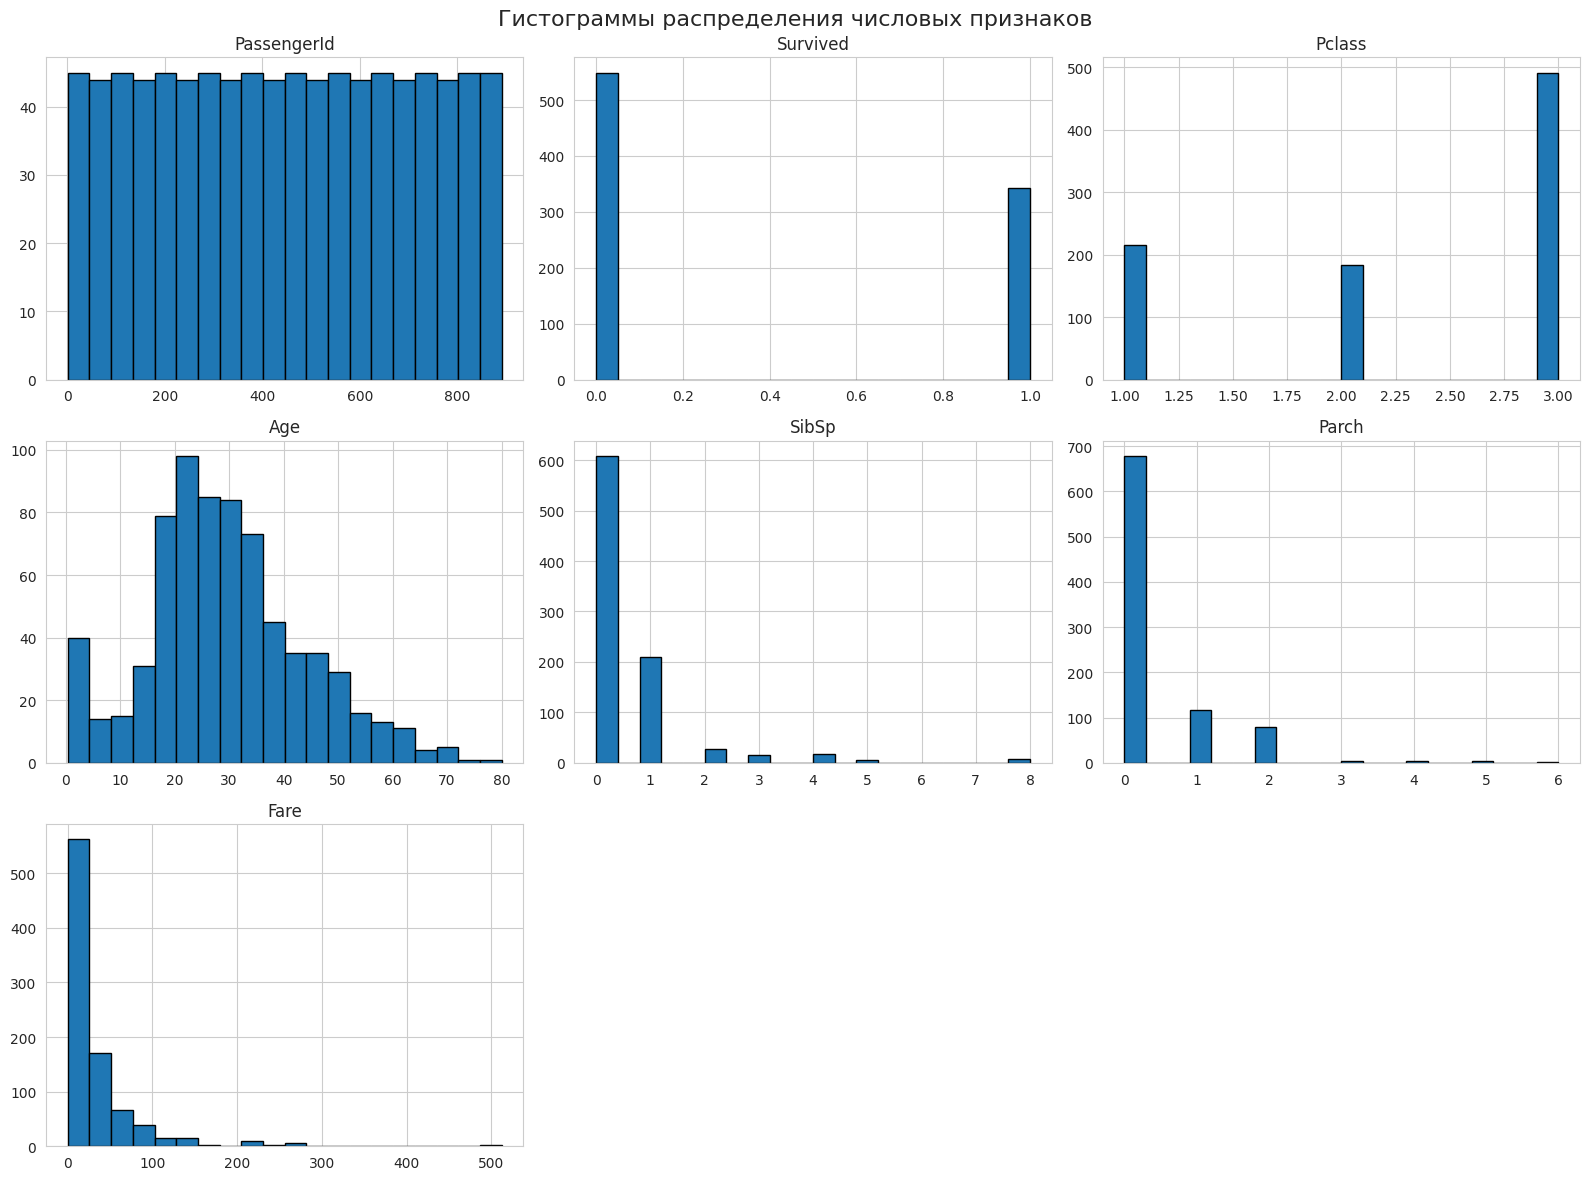

In [90]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

df[numeric_cols].hist(bins=20, figsize=(16, 12), edgecolor='black')
plt.suptitle("Гистограммы распределения числовых признаков", fontsize=16)
plt.tight_layout()
plt.show()

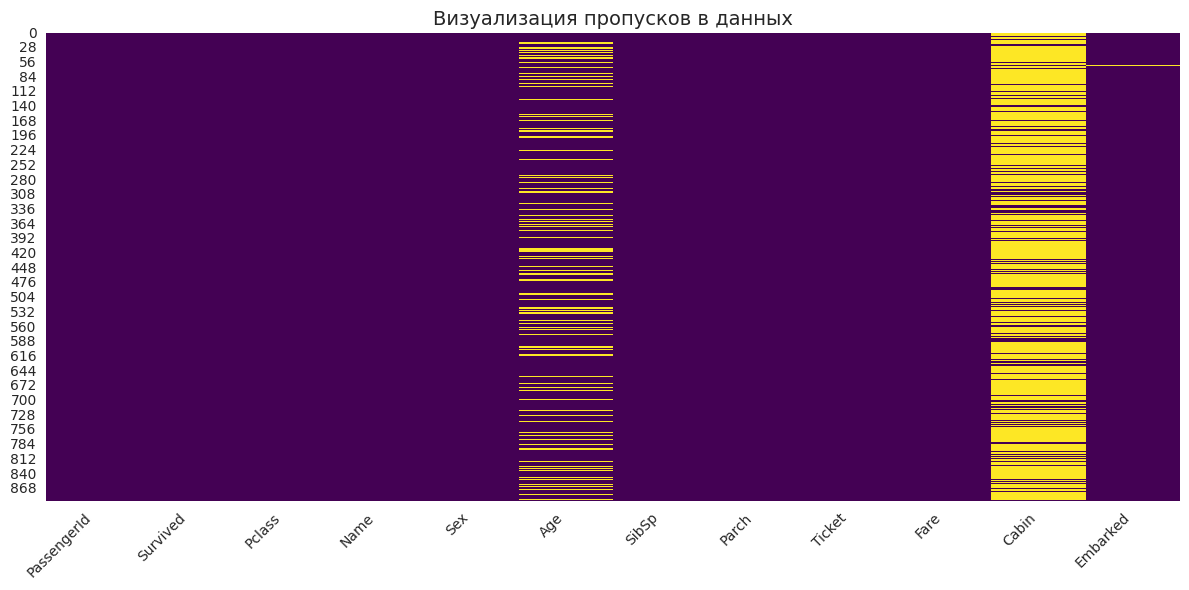

In [91]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Визуализация пропусков в данных", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

In [92]:
missing_before = df.isna().sum()
print("Пропуски до обработки:")
missing_before

Пропуски до обработки:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [93]:
age_mean = df['Age'].mean()
age_median = df['Age'].median()

print(f"Средний возраст: {age_mean:.2f}")
print(f"Медианный возраст: {age_median:.2f}")

df['Age'] = df['Age'].fillna(age_median)

def age_group(age):
    if age < 18:
        return 'Child'
    elif age < 45:
        return 'Young (18-44)'
    elif age < 60:
        return 'Middle (45-59)'
    elif age < 75:
        return 'Elderly (60-74)'
    else:
        return 'Old (75-89)'

df['Age_group'] = df['Age'].apply(age_group)

df['Age_group'].value_counts()

Средний возраст: 29.70
Медианный возраст: 28.00


,count
Age_group,
Young (18-44),663
Child,113
Middle (45-59),89
Elderly (60-74),25
Old (75-89),1


In [94]:
embarked_mode = df['Embarked'].mode()[0]
print(f"Мода для Embarked: {embarked_mode}")

df['Embarked'] = df['Embarked'].fillna(embarked_mode)

Мода для Embarked: S


In [95]:
print("Количество пропусков в Cabin:", df['Cabin'].isna().sum())
df['CabinLetter'] = df['Cabin'].fillna('Unknown').str[0]
df['HasCabin'] = df['Cabin'].notna().astype(int)
df[['Cabin', 'CabinLetter', 'HasCabin']].head(10)

Количество пропусков в Cabin: 687


,Cabin,CabinLetter,HasCabin
0,NaN,U,0
1,C85,C,1
2,NaN,U,0
3,C123,C,1
4,NaN,U,0
5,NaN,U,0
6,E46,E,1
7,NaN,U,0
8,NaN,U,0
9,NaN,U,0


In [96]:
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
original_df = pd.read_csv(url)
df['Pclass'] = original_df['Pclass']

pclass_map = {1: 'F', 2: 'S', 3: 'T'}
df['Pclass'] = df['Pclass'].map(pclass_map).astype('category')
df['Pclass'].value_counts()

,count
Pclass,
T,491
F,216
S,184


In [97]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False) #запятая -> любое количество пробелов -> взять все до первой точки

print("Уникальные титулы:")
print(df['Title'].value_counts())

Уникальные титулы:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Col               2
Mlle              2
Major             2
Ms                1
Mme               1
Don               1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [98]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

df['Sex'].value_counts()

,count
Sex,
0,577
1,314


In [99]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


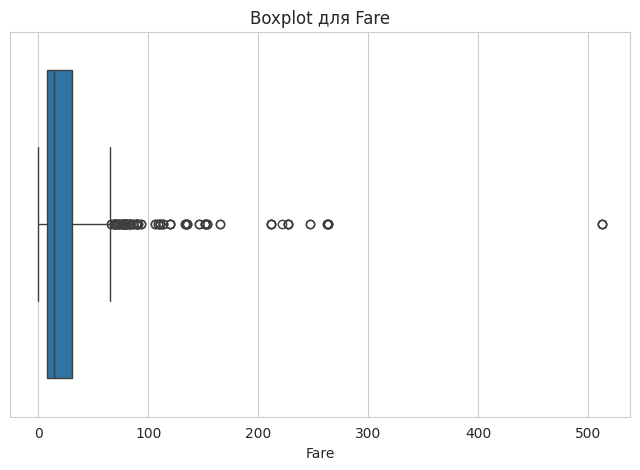

In [100]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot для Fare")
plt.show()

In [101]:
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_fare = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Нижняя граница = {lower_bound:.2f}")
print(f"Верхняя граница = {upper_bound:.2f}")
print(f"Количество выбросов в Fare = {outliers_fare.shape[0]}")

Q1 = 7.91
Q3 = 31.00
IQR = 23.09
Нижняя граница = -26.72
Верхняя граница = 65.63
Количество выбросов в Fare = 116


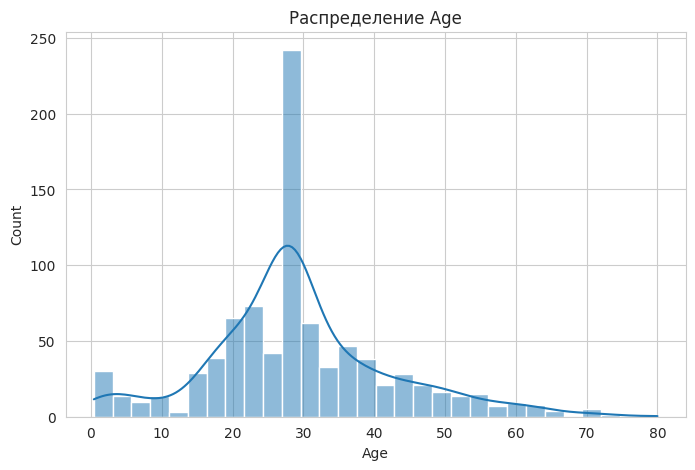

In [102]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Распределение Age")
plt.show()

95-й перцентиль Fare: 112.08
5-й перцентиль Fare: 7.22


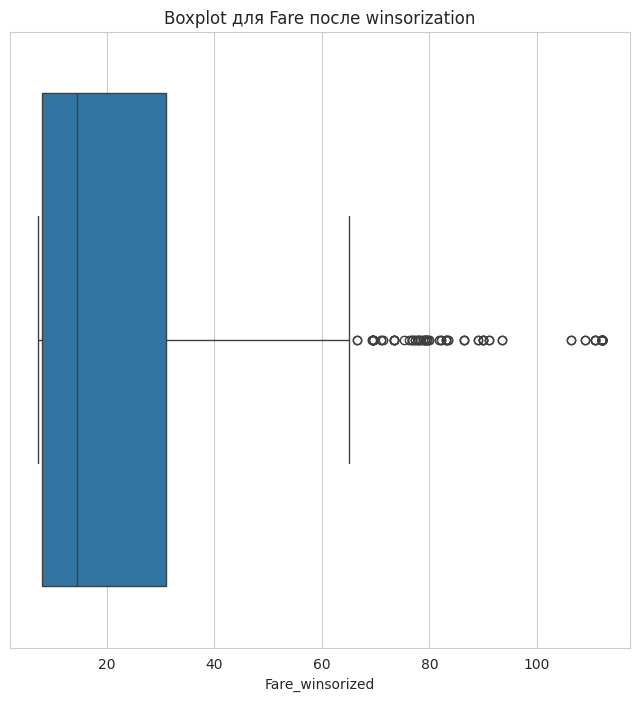

In [103]:
fare_95 = df['Fare'].quantile(0.95)
fare_05 = df['Fare'].quantile(0.05)
print(f"95-й перцентиль Fare: {fare_95:.2f}")
print(f"5-й перцентиль Fare: {fare_05:.2f}")

df['Fare_winsorized'] = df['Fare'].clip(upper=fare_95, lower=fare_05)

plt.figure(figsize=(8, 8))
sns.boxplot(x=df['Fare_winsorized'])
plt.title("Boxplot для Fare после winsorization")
plt.show()

95-й перцентиль Age: 54.00


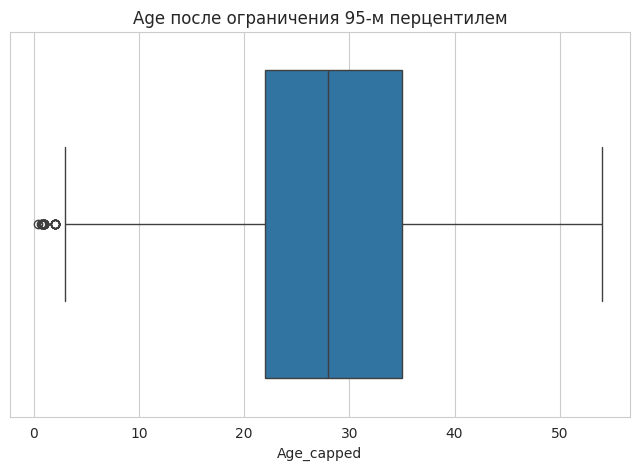

In [104]:
age_95 = df['Age'].quantile(0.95)
print(f"95-й перцентиль Age: {age_95:.2f}")

df['Age_capped'] = df['Age'].clip(upper=age_95)

plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Age_capped'])
plt.title("Age после ограничения 95-м перцентилем")
plt.show()

Средняя выживаемость по классам:
Pclass
F    0.629630
S    0.472826
T    0.242363
Name: Survived, dtype: float64


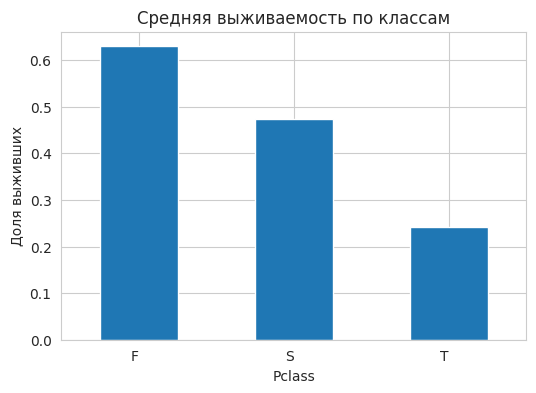

In [105]:
survival_by_class = df.groupby('Pclass', observed=False)['Survived'].mean()
print("Средняя выживаемость по классам:")
print(survival_by_class)

plt.figure(figsize=(6, 4))
survival_by_class.plot(kind='bar')
plt.xticks(rotation=0, ha='right')
plt.title("Средняя выживаемость по классам")
plt.ylabel("Доля выживших")
plt.show()

In [106]:
group_pclass_sex = df.groupby(['Pclass', 'Sex'], observed=False)['Survived'].mean()
print("Выживаемость по Pclass и Sex:")
group_pclass_sex

Выживаемость по Pclass и Sex:


Pclass  Sex
F       0      0.368852
        1      0.968085
S       0      0.157407
        1      0.921053
T       0      0.135447
        1      0.500000
Name: Survived, dtype: float64

In [107]:
median_age_by_embarked = df.groupby('Embarked')['Age'].median()
print("Медианный возраст по портам посадки:")
print(median_age_by_embarked)
df.groupby('Embarked')['Age'].describe()

Медианный возраст по портам посадки:
Embarked
C    28.0
Q    28.0
S    28.0
Name: Age, dtype: float64


,count,mean,std,min,25%,50%,75%,max
Embarked,,,,,,,,
C,168.0,30.178095,13.616930,0.42,23.375,28.0,36.0,71.0
Q,77.0,28.032468,10.082338,2.00,28.000,28.0,28.0,70.5
S,646.0,29.307663,13.172986,0.67,22.000,28.0,36.0,80.0


In [108]:
pivot_table = pd.pivot_table(
    df,
    values='Survived',
    index='Title',
    columns='Age_group',
    aggfunc='mean'
)

print("Сводная таблица выживаемости (новые признаки):")
pivot_table

Сводная таблица выживаемости (новые признаки):


Age_group,Child,Elderly (60-74),Middle (45-59),Old (75-89),Young (18-44)
Title,,,,,
Capt,NaN,0.000000,NaN,NaN,NaN
Col,NaN,0.000000,1.000000,NaN,NaN
Don,NaN,NaN,NaN,NaN,0.000000
Dr,NaN,NaN,0.666667,NaN,0.250000
Jonkheer,NaN,NaN,NaN,NaN,0.000000
Lady,NaN,NaN,1.000000,NaN,NaN
Major,NaN,NaN,0.500000,NaN,NaN
Master,0.583333,NaN,NaN,NaN,0.500000
Miss,0.666667,1.000000,0.714286,NaN,0.707317


In [109]:
print("Сводная таблица выживаемости (класс и возраст):")
pd.pivot_table(
    df,
    values='Survived',
    index='Pclass',
    columns='Sex',
    aggfunc='mean'
)

Сводная таблица выживаемости (класс и возраст):


/tmp/ipykernel_12096/3871613459.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


Sex,0,1
Pclass,,
F,0.368852,0.968085
S,0.157407,0.921053
T,0.135447,0.500000


In [110]:
print("Сводная таблица выживаемости (возрастная группа и класс):")
pd.pivot_table(
    df,
    values='Survived',
    index='Age_group',
    columns='Pclass',
    aggfunc='mean'
)

Сводная таблица выживаемости (возрастная группа и класс):


/tmp/ipykernel_12096/4115584316.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


Pclass,F,S,T
Age_group,,,
Child,0.916667,0.913043,0.371795
Elderly (60-74),0.250000,0.250000,0.200000
Middle (45-59),0.540000,0.380952,0.055556
Old (75-89),1.000000,NaN,NaN
Young (18-44),0.678832,0.419118,0.225641


In [111]:
missing_after = df.isna().sum()

total_missing_before = missing_before.sum()
total_missing_after = missing_after.sum()

filled_percent = ((total_missing_before - total_missing_after) / total_missing_before) * 100

print("Пропуски после обработки:")
print(missing_after)
print(f"Процент заполненных пропусков: {filled_percent:.2f}%")

Пропуски после обработки:
PassengerId          0
Survived             0
Pclass               0
Name                 0
Sex                  0
Age                  0
SibSp                0
Parch                0
Ticket               0
Fare                 0
Cabin              687
Embarked             0
Age_group            0
CabinLetter          0
HasCabin             0
Title                0
FamilySize           0
IsAlone              0
Fare_winsorized      0
Age_capped           0
dtype: int64
Процент заполненных пропусков: 20.67%


In [112]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Количество уникальных значений в категориальных признаках:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()}")

Количество уникальных значений в категориальных признаках:
Pclass: 3
Name: 891
Ticket: 681
Cabin: 147
Embarked: 3
Age_group: 5
CabinLetter: 9
Title: 17


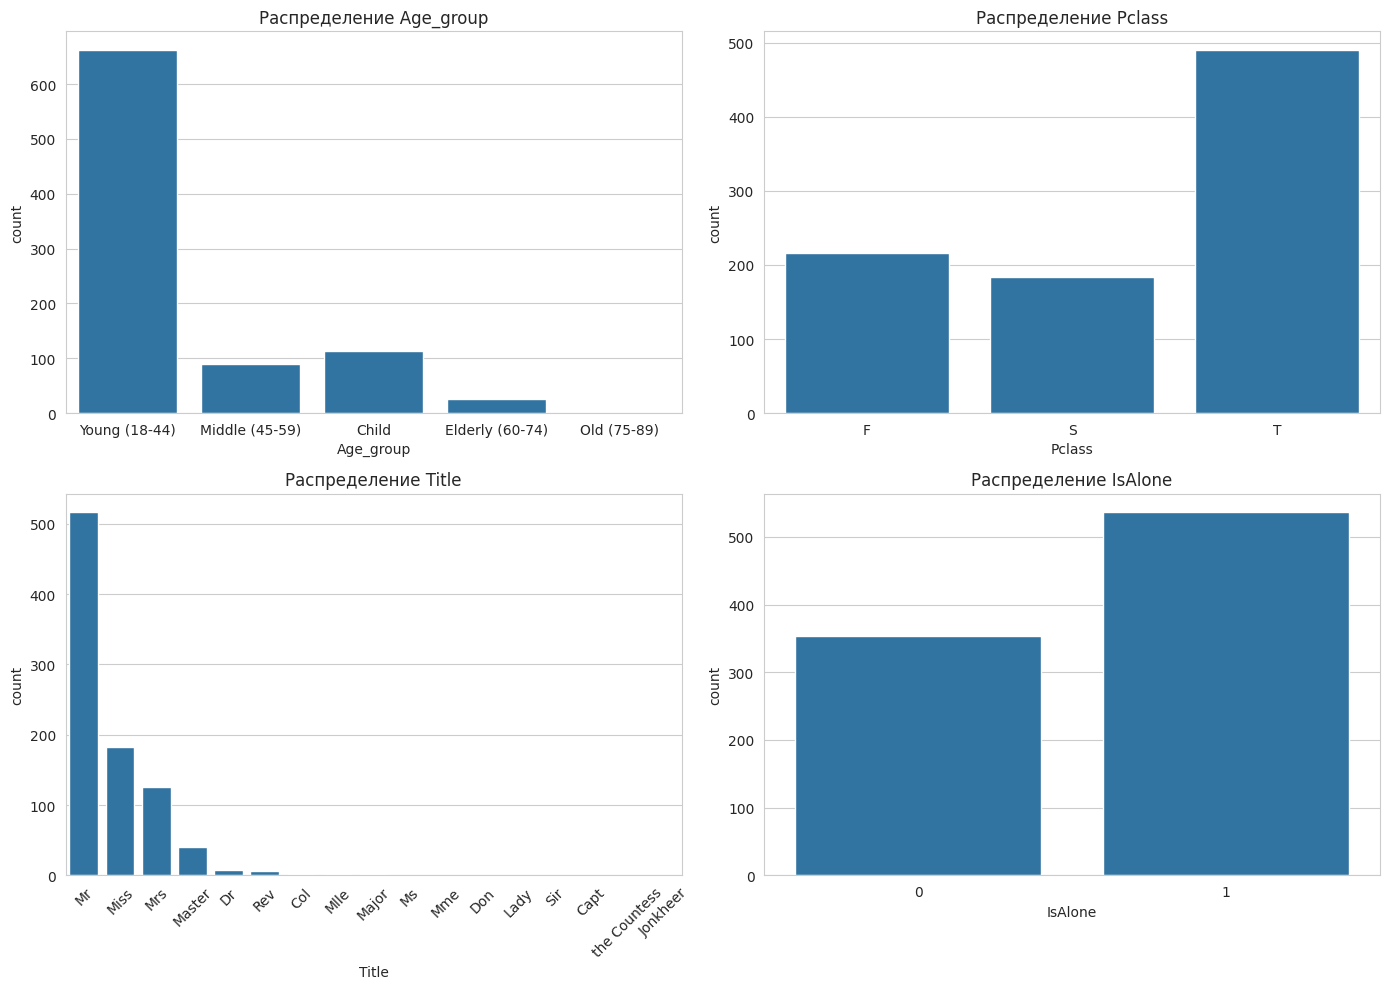

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df, x='Age_group', ax=axes[0, 0])
axes[0, 0].set_title("Распределение Age_group")

sns.countplot(data=df, x='Pclass', ax=axes[0, 1])
axes[0, 1].set_title("Распределение Pclass")

sns.countplot(data=df, x='Title', order=df['Title'].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title("Распределение Title")
axes[1, 0].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='IsAlone', ax=axes[1, 1])
axes[1, 1].set_title("Распределение IsAlone")

plt.tight_layout()
plt.show()

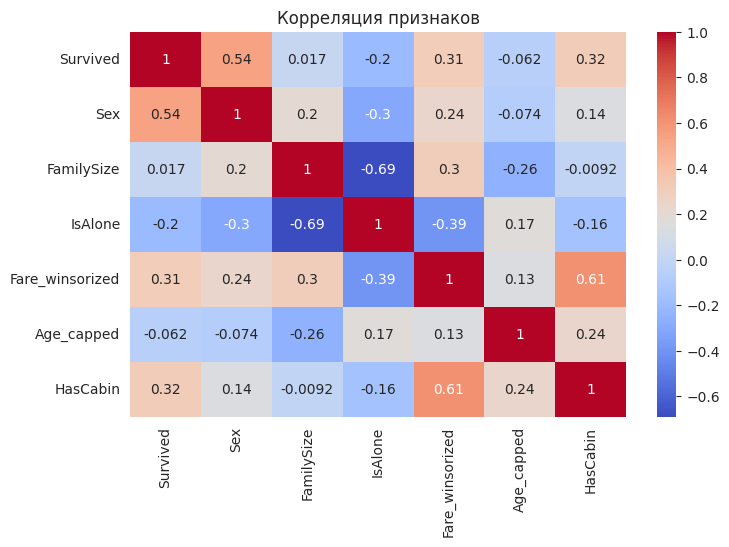

In [117]:
corr_cols = [
    'Survived',
    'Sex',
    'FamilySize',
    'IsAlone',
    'Fare_winsorized',
    'Age_capped',
    'HasCabin'
]

corr_matrix = df[corr_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Корреляция признаков")
plt.show()

In [115]:
df.to_csv('titanic_cleaned.csv', index=False)
print("Файл titanic_cleaned.csv сохранён.")

Файл titanic_cleaned.csv сохранён.



# Лабораторная работа №6

## Очистка и трансформация данных. pandas

**Студент:** Фамилия Имя
**Группа:** P3120

**Ссылка на Colab:** [Открыть ноутбук](https://colab.research.google.com/drive/1ozo--qB4bAbOz2xaEyFk5tm2So4gF0s6?usp=sharing)

---

# 1. Введение

Предобработка данных является ключевым этапом анализа, поскольку реальные данные часто содержат пропуски, выбросы и неоднородные структуры. Качественная очистка и трансформация позволяют не только улучшить качество данных, но и выявить скрытые зависимости между признаками.

---

# 2. Цель работы

Освоить методы очистки и трансформации данных, а также провести анализ факторов, влияющих на выживаемость пассажиров, с использованием библиотеки pandas.

---

# 3. Описание набора данных

Набор данных Titanic содержит информацию о пассажирах, включая демографические характеристики (пол, возраст), социально-экономические признаки (класс билета, стоимость), а также информацию о семье и поездке.

Целевой переменной является признак **Survived**.

---

# 4. Первичный анализ

Анализ показал:

* наличие пропусков в Cabin, Age и Embarked
* сильную асимметрию признака Fare
* наличие экстремальных значений (до 512.33)
* концентрацию возраста вокруг 20–35 лет

---

# 5. Статистика датафрейма

* средний возраст: **29.36**
* медианный возраст: **28**
* средняя стоимость билета: **32.20**
* медианная стоимость: **14.45**

Разница между средним и медианой для Fare указывает на наличие сильных выбросов.

Рисунок 1 — Визуализация пропусков в данных

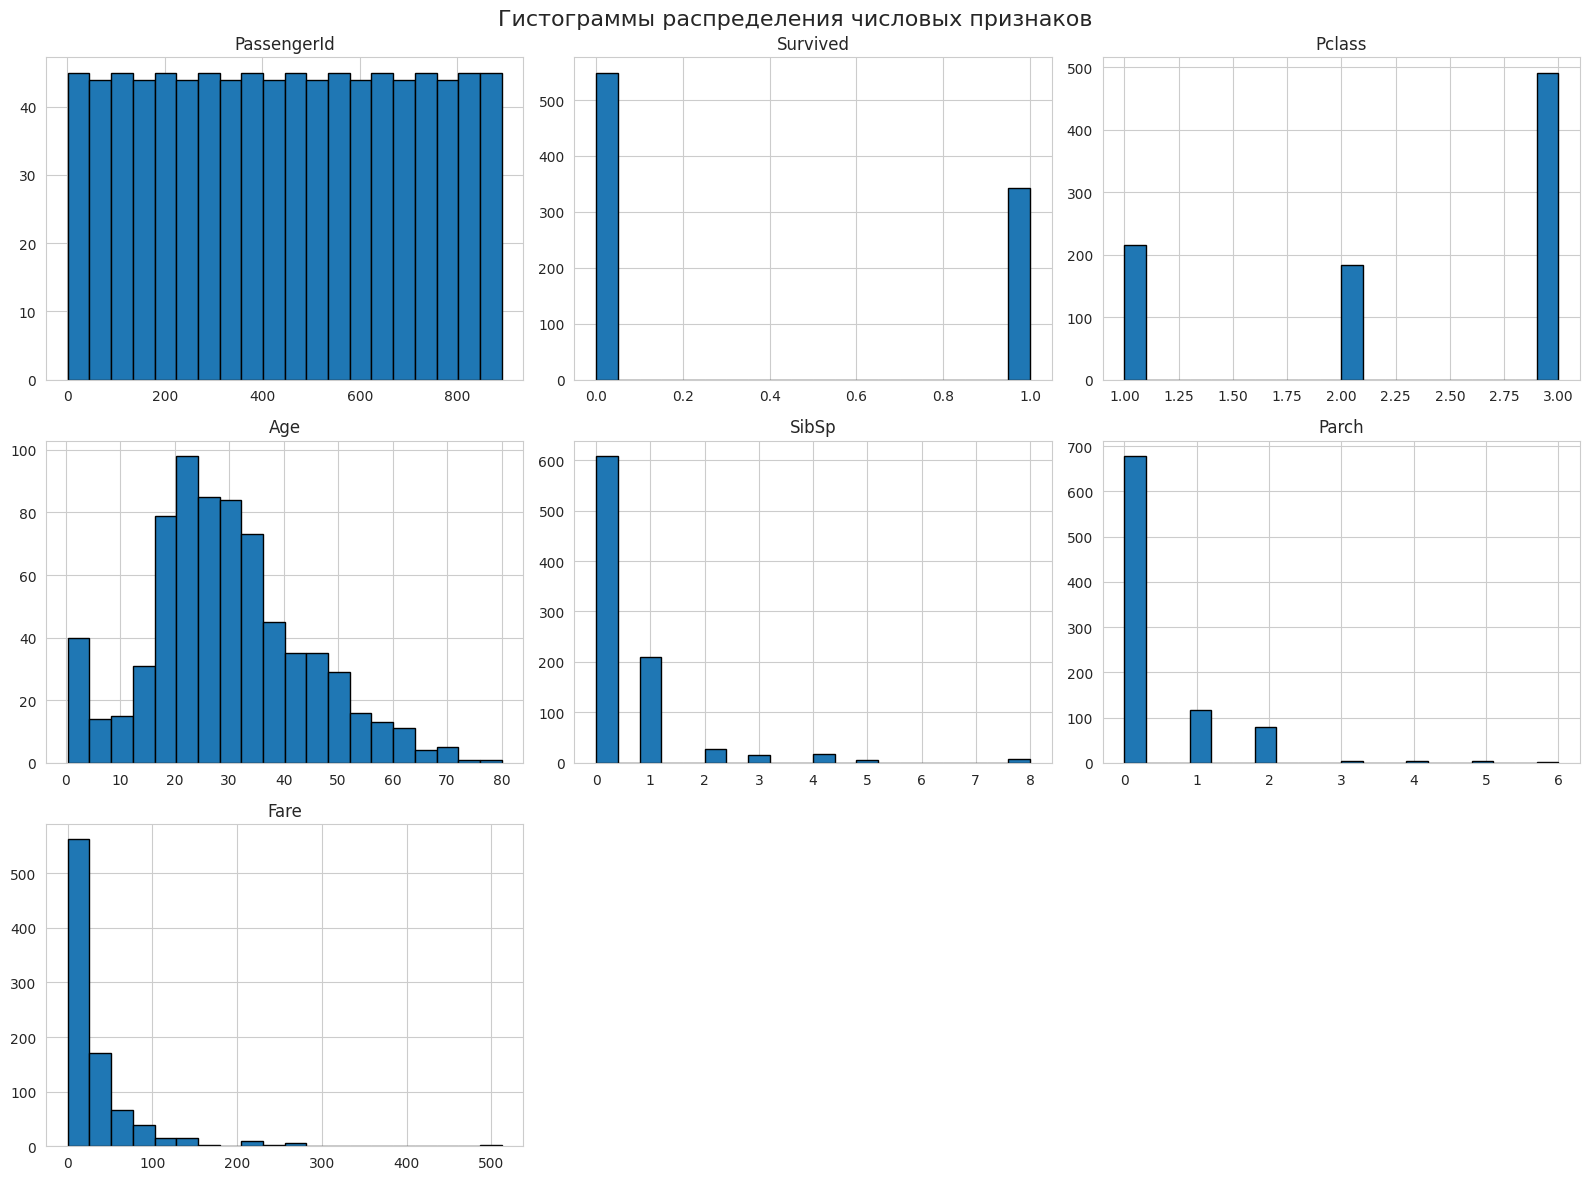
---

# 6. Визуализация пропусков

Анализ пропусков показал:

* Cabin содержит наибольшее количество пропущенных значений
* Age имеет частичные пропуски
* Embarked практически полный


#####Рисунок 2 — Визуализация пропусков в данных
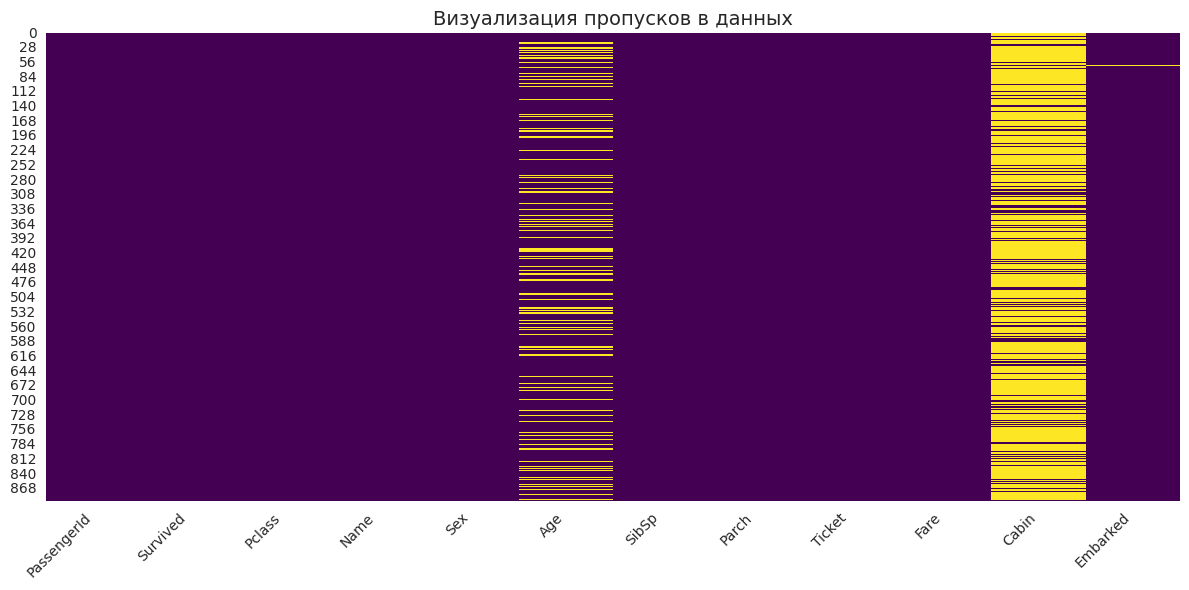
---

# 7. Обработка пропусков

Пропуски были обработаны следующим образом:

* Age заполнен медианой
* Embarked заполнен модой
* Cabin преобразован в новые признаки

---

# 8. Методы заполнения

Использование медианы для Age позволило избежать искажения данных выбросами, а использование моды для Embarked — сохранить наиболее вероятное значение.

---

# 9. Результаты обработки

Было заполнено **20.67% пропусков**, что значительно повысило полноту данных.

Однако заполнение медианой привело к концентрации значений возраста около 28 лет, что повлияло на последующий анализ.

---

# 10. Трансформация данных

Данные были преобразованы для повышения их информативности и удобства анализа.

---

# 11. Созданные признаки

Созданы следующие признаки:

* Age_group — возрастная категория
* Title — титул пассажира
* FamilySize — размер семьи
* IsAlone — путешествие в одиночку
* CabinLetter — палуба
* HasCabin — наличие каюты
* Fare_winsorized — стоимость билета без выбросов
* Age_capped — ограниченный возраст

---

# 12. Преобразования типов

* Pclass преобразован в категориальный признак
* Sex преобразован в числовой формат

---

# 13. Обработка выбросов

Выбросы были выявлены в признаке Fare.

Рисунок 3 — Boxplot стоимости билета

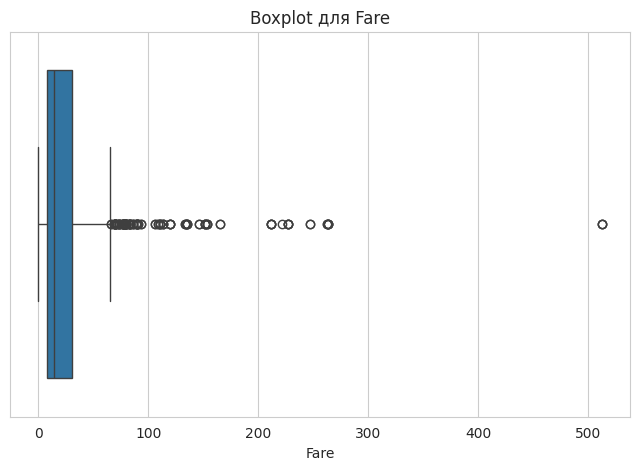
---

# 14. Выявленные выбросы

Максимальное значение Fare (512.33) значительно превышает медианное (14.45), что указывает на наличие экстремальных значений.

---

# 15. Методы обработки

* применена winsorization
* ограничены экстремальные значения

Это позволило снизить влияние выбросов на анализ.

Рисунок 4 — Boxplot стоимости билета после применения winsorization

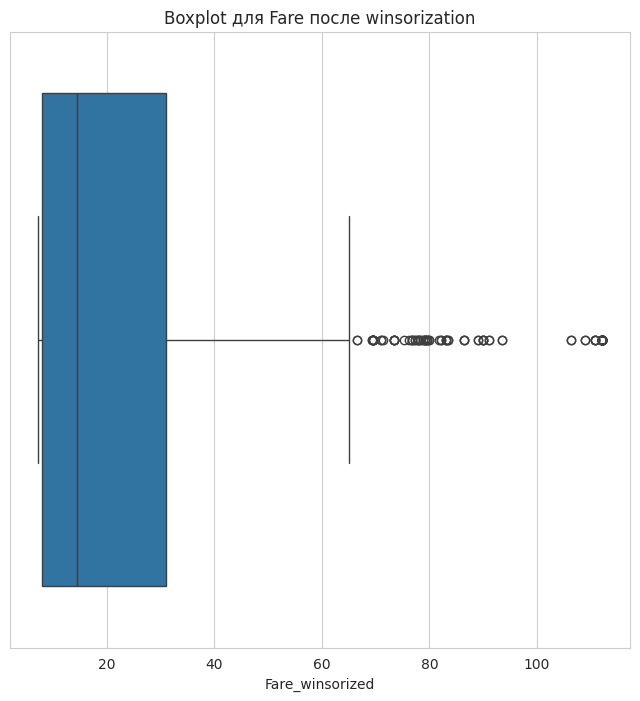

---

# 16. Агрегация и анализ

## Выживаемость по классам

* F: **62.96%**
* S: **47.28%**
* T: **24.24%**

Чётко наблюдается снижение выживаемости с понижением класса.

---

## Выживаемость по полу и классу

Женщины:

* до **96.8%** в первом классе

Мужчины:

* от **13.5% до 36.9%**

👉 Пол является наиболее значимым фактором выживания.

---

# 17. Сводные статистики

## Распределение признаков

* Mr — 517 (доминирующая группа)
* Young (18–44) — 663
* одиночные пассажиры — 537

Это указывает на преобладание молодых мужчин, путешествующих в одиночку.

Рисунок 5 — Распределение новых признаков

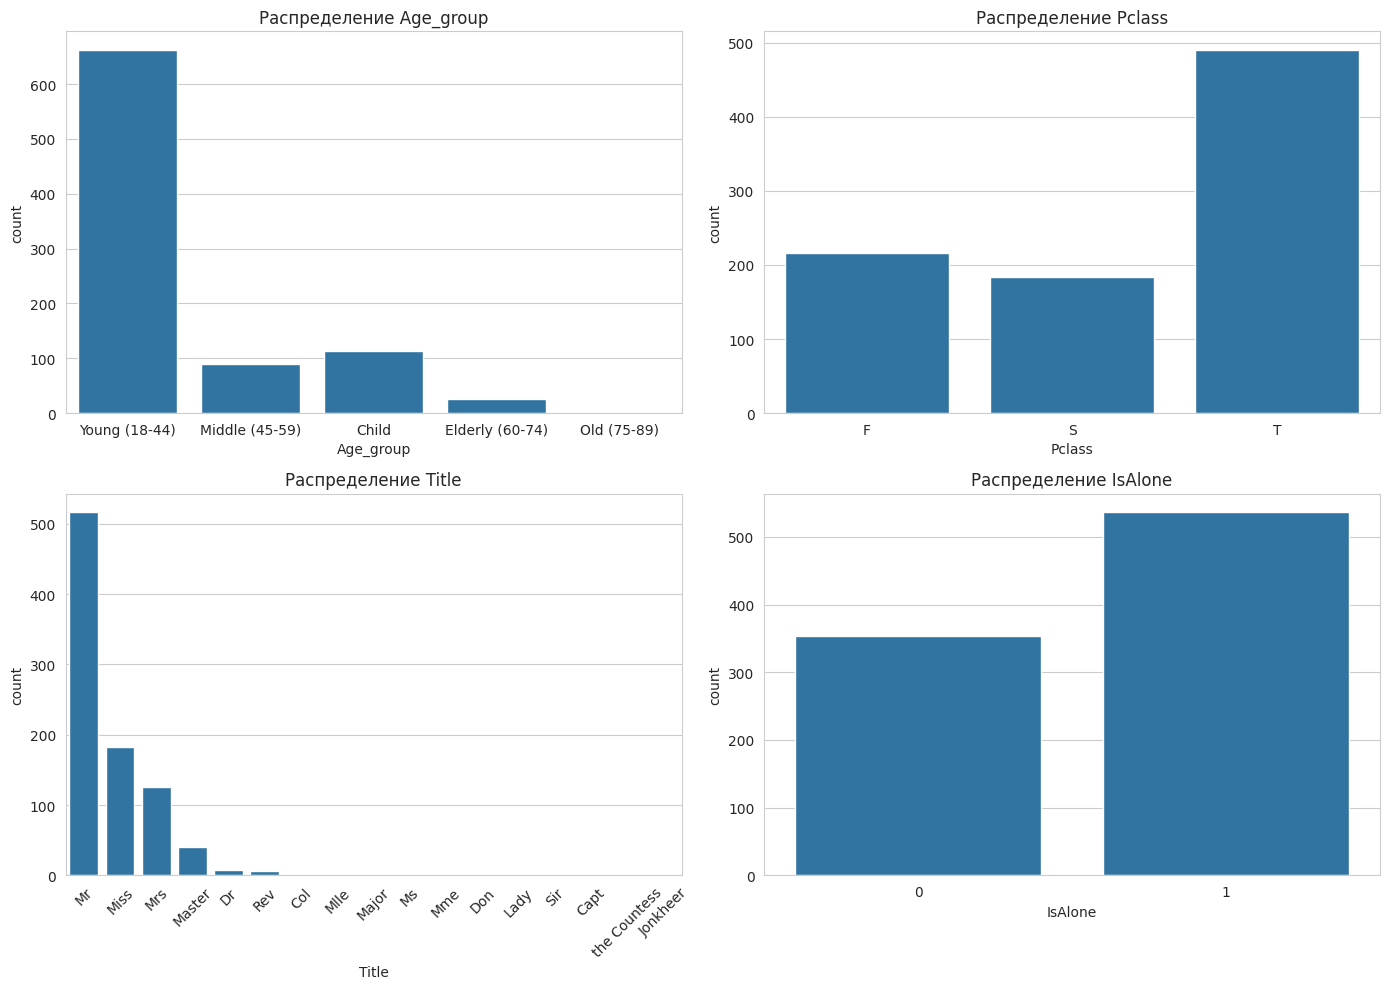

---

## Корреляционный анализ

Рисунок 6 - Матрица корреляции

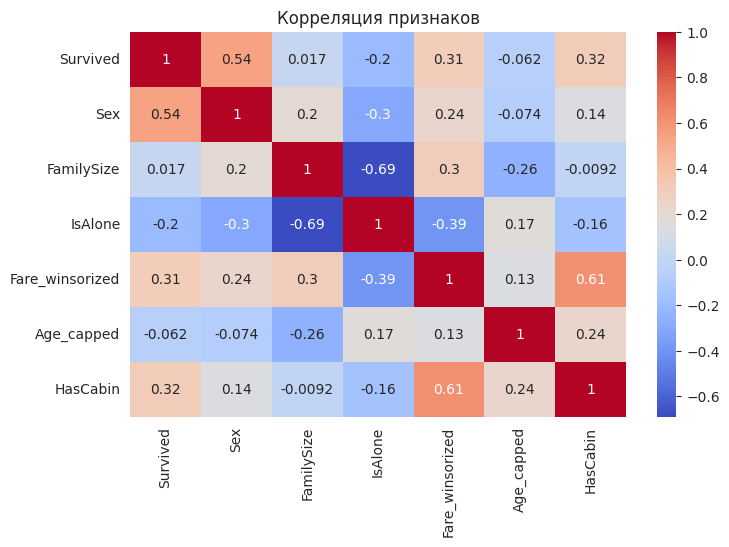


Наиболее значимые зависимости:

### 1. Пол и выживаемость

* **0.54** — сильная положительная связь
  👉 женщины значительно чаще выживали

---

### 2. Стоимость билета и наличие каюты

* **0.61** — сильная связь
  👉 дорогие билеты связаны с наличием кают

---

### 3. Размер семьи и одиночество

* **-0.69** — сильная отрицательная связь
  👉 логично: чем больше семья, тем ниже вероятность быть одному

---

### 4. Стоимость билета и выживаемость

* **0.31** — умеренная связь
  👉 более дорогие билеты повышают шансы выживания

---

### 5. Наличие каюты и выживаемость

* **0.32**
  👉 косвенно отражает социальный статус

---

### 6. Возраст и выживаемость

* **-0.06** — практически отсутствует связь
  👉 возраст сам по себе не является значимым фактором

---

# 18. Визуализации

Были построены:

* гистограммы распределений
* визуализация пропусков
* boxplot для выявления выбросов
* распределения новых признаков
* графики выживаемости
* матрица корреляции
* сводные таблицы

---

# 19. Заключение

В ходе работы была выполнена комплексная предобработка данных, включая очистку, трансформацию и анализ. Были выявлены ключевые факторы, влияющие на выживаемость пассажиров.

---

# 20. Результаты работы

* обработаны пропуски
* устранены выбросы
* созданы новые признаки
* выполнен анализ зависимостей
* построены визуализации
* рассчитана корреляция

---

# 21. Выводы

1. Пол является наиболее значимым фактором выживания.
2. Класс билета напрямую влияет на вероятность выживания.
3. Социально-экономический статус (Fare, Cabin) играет важную роль.
4. Возраст оказывает слабое влияние на выживаемость.
5. Большинство пассажиров — молодые мужчины, путешествующие в одиночку.
6. Создание новых признаков существенно улучшило анализ данных.

---
